# Reproducing Valenti et al. (2019): QFM Geometry of RBM Neural Quantum States

**Paper:** _Scalable Neural-Network Quantum States and Correlations in the Transverse-Field Ising Model_ (Valenti, Mansfield, Koch-Janusz, 2019)

This notebook reproduces the core figures of the paper using a **small system (N=8)** so that every result can be checked against exact diagonalization.  
The code is structured to scale to the paper's N=28 by changing a single parameter.

---

### What this notebook shows

| Figure                                | What it demonstrates                                                                    |
| ------------------------------------- | --------------------------------------------------------------------------------------- |
| **Plot 1** – Energy convergence       | SR successfully finds the ground state for all h                                        |
| **Plot 2** – QFM spectrum evolution   | Universal initial spectrum → phase-specific converged spectrum                          |
| **Plot 3** – Converged QFM spectra    | Rank-deficient (ordered) vs dense exponential (critical) vs symmetric kink (disordered) |
| **Plot 4** – Eigenvector entanglement | Large eigenvalues = least entangled; correlations live in the flat valleys              |

---

### Key paper claims to verify

1. **Universal initial dynamics**: first ~25 epochs, all h look identical
2. **Rank deficiency in ordered phase** (h < 1): S becomes nearly singular
3. **Dense exponential decay at criticality** (h = 1): all eigenvalues populated
4. **Symmetry kink at N(N+1)/2**: visible in critical and disordered converged spectra
5. **Raw weights tell you nothing**: the QFM spectrum is the diagnostic
6. **Entanglement stratification**: largest eigenvectors have near-zero entanglement


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Resolve src/ regardless of kernel working directory
_nb_dir = (
    Path(os.path.abspath("")).parent
    if Path(os.path.abspath("")).name == "notebooks"
    else Path(os.path.abspath(""))
)
_src_dir = _nb_dir / "src"
if not _src_dir.exists():
    # Fallback: try sibling of current directory
    _src_dir = Path(os.path.abspath("")) / "src"
sys.path.insert(0, str(_src_dir))

from complex_rbm import (
    init_rbm,
    log_psi,
    psi_squared_ratio,
    psi_ratio,
    compute_gradients,
    metropolis_sampler,
    local_energy_tfim,
    build_qfm,
    qfm_spectrum,
    eigenvector_entanglement,
    sr_update,
)
from tfim_exact import TFIMExact

try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("default")
fig_dpi = 100
Path(_nb_dir / "results").mkdir(parents=True, exist_ok=True)
print(f"src path: {_src_dir}")
print("Imports OK.")

src path: /home/ronin/Dev/rbm_neuralquantumstates/src
Imports OK.


## Hyperparameters

All values match the paper. To scale to N=28, change `N` — everything else adjusts automatically.

| Parameter           | Small (here) | Paper |
| ------------------- | ------------ | ----- |
| Visible units N     | 8            | 28    |
| Hidden ratio α      | 3            | 3     |
| Hidden units M = αN | 24           | 84    |
| Learning rate η     | 0.01         | 0.01  |
| SR regularisation ε | 0.001        | 0.001 |
| Epochs              | 300          | 2000+ |


In [3]:
# ── Change only N to scale up ──────────────────────────────────────────────
N = 8  # paper uses 28; N=8 allows exact diagonalization check
# ──────────────────────────────────────────────────────────────────────────

alpha = 3  # hidden-to-visible ratio (paper: α = M/N = 3)
M = alpha * N  # 24 hidden units for N=8

# Optimization — paper values
eta = 0.01  # learning rate
epsilon = 0.001  # SR diagonal regularisation
n_epochs = 300  # paper uses 2000+; 300 sufficient to see all features at N=8
n_samples = 1000  # MC samples per epoch

# Transverse fields to sweep (paper uses these exact 5 values)
h_values = [0.0, 0.6, 1.0, 1.4, 2.0]
h_labels = {
    0.0: "h=0.0 (FM)",
    0.6: "h=0.6 (FM)",
    1.0: "h=1.0 (critical)",
    1.4: "h=1.4 (PM)",
    2.0: "h=2.0 (PM)",
}
h_colors = {
    0.0: "#1f77b4",
    0.6: "#17becf",
    1.0: "#d62728",
    1.4: "#ff7f0e",
    2.0: "#8c564b",
}

# QFM snapshot epochs (for Plot 2)
qfm_snapshot_epochs = {0, 10, 25, 50, 100, 200}

# Symmetry kink index: N(N+1)/2
kink_idx = N * (N + 1) // 2  # 36 for N=8

n_params = N + M + N * M
print(f"System:  N={N} spins,  M={M} hidden units (α={alpha})")
print(
    f"Params:  {n_params} total  ({N} visible biases + {M} hidden biases + {N*M} weights)"
)
print(f"Symmetry kink index: N(N+1)/2 = {kink_idx}")
print(f"h values: {h_values}")

System:  N=8 spins,  M=24 hidden units (α=3)
Params:  224 total  (8 visible biases + 24 hidden biases + 192 weights)
Symmetry kink index: N(N+1)/2 = 36
h values: [0.0, 0.6, 1.0, 1.4, 2.0]


## Exact Diagonalization (Sanity Check)

For N=8 we can compute exact ground state energies using full Hamiltonian diagonalization.
These serve as reference values to verify the VMC results.


In [4]:
exact_energies = {}
print(f"Exact ground state energies (N={N}, J=1)")
print(f"{'h':>6}    E0         E0/N")
print("-" * 35)

for h in h_values:
    tfim = TFIMExact(L=N, J=1.0, g=h)  # g ≡ h in TFIMExact
    E0 = tfim.groundstate_energy()  # uses full ED (feasible for N≤14)
    exact_energies[h] = E0
    print(f"  {h:.1f}    {E0:8.4f}    {E0/N:6.4f}")

print("\nExact energies computed.")

Exact ground state energies (N=8, J=1)
     h    E0         E0/N
-----------------------------------
  0.0     -8.0000    -1.0000
  0.6     -8.7408    -1.0926
  1.0    -10.2517    -1.2815
  1.4    -12.6962    -1.5870
  2.0    -17.0182    -2.1273

Exact energies computed.


## Training Loop with QFM Tracking

The key difference from a standard VMC loop: we compute and store the full
QFM eigenspectrum at specified epoch snapshots. This lets us watch how the
geometry of the learning landscape reorganises from the universal initial
profile into a phase-specific converged shape.


In [5]:
def train_with_qfm_tracking(
    N,
    M,
    h,
    J=1.0,
    n_epochs=300,
    n_samples=1000,
    lr=0.01,
    sr_reg=0.001,
    qfm_snapshot_epochs=None,
    n_qfm_samples=500,
    seed=None,
):
    """SR training that records QFM snapshots during optimisation.

    Args:
        N: visible units (system size)
        M: hidden units
        h: transverse field
        J: Ising coupling
        n_epochs: training epochs
        n_samples: MC samples per epoch
        lr: learning rate η
        sr_reg: SR regularisation ε
        qfm_snapshot_epochs: set of epochs at which to record QFM spectrum
        n_qfm_samples: samples used for QFM estimation (can differ from n_samples)
        seed: random seed

    Returns:
        dict with 'energies', 'qfm_snapshots', 'final_theta',
        'final_eigs', 'final_evecs'
    """
    if qfm_snapshot_epochs is None:
        qfm_snapshot_epochs = set()

    rng = np.random.RandomState(seed)
    theta = init_rbm(N, M, scale=0.01, complex_params=False, seed=seed)

    history = {
        "energies": [],
        "variances": [],
        "accept_rates": [],
        "qfm_snapshots": {},  # epoch -> array of eigenvalues
    }

    for epoch in range(n_epochs):
        # ── MCMC sampling ───────────────────────────────────────────────
        configs, acc_rate = metropolis_sampler(n_samples, N, theta, N, rng=rng)

        # ── Local energies ──────────────────────────────────────────────
        E_locs = np.array(
            [local_energy_tfim(sigma, theta, N, J=J, h=h) for sigma in configs]
        )
        E_mean = float(np.real(np.mean(E_locs)))
        E_var = float(np.real(np.var(E_locs)))

        # ── QFM snapshot ────────────────────────────────────────────────
        if epoch in qfm_snapshot_epochs:
            snap_configs, _ = metropolis_sampler(
                n_qfm_samples, N, theta, N, rng=np.random.RandomState(epoch)
            )
            S_snap, _ = build_qfm(snap_configs, theta)
            eigs_snap, _ = qfm_spectrum(S_snap)
            history["qfm_snapshots"][epoch] = eigs_snap

        # ── SR update ────────────────────────────────────────────────────
        delta = sr_update(configs, np.real(E_locs), theta, sr_reg=sr_reg)
        for k in theta:
            theta[k] -= lr * np.real(delta[k])

        history["energies"].append(E_mean)
        history["variances"].append(E_var)
        history["accept_rates"].append(acc_rate)

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(
                f"  epoch {epoch+1:4d}: E = {E_mean:8.4f} ± {np.sqrt(E_var/n_samples):.4f},"
                f"  acc = {acc_rate:.3f}"
            )

    # ── Final QFM (large sample for quality) ────────────────────────────
    final_configs, _ = metropolis_sampler(
        2000, N, theta, N, rng=np.random.RandomState(9999)
    )
    S_final, _ = build_qfm(final_configs, theta)
    eigs_final, evecs_final = qfm_spectrum(S_final)

    history["final_theta"] = theta
    history["final_eigs"] = eigs_final
    history["final_evecs"] = evecs_final
    return history


print("Training function defined.")

Training function defined.


## Run: Sweep Over h Values

Training is run independently for each transverse field.  
At N=8 this takes a few minutes; at N=28 expect ~hours without parallelism.


In [6]:
results = {}
GLOBAL_SEED = 42

for h in h_values:
    print(f"\n{'='*60}")
    print(f"Training: h = {h}  ({h_labels[h]})")
    print(f"{'='*60}")
    results[h] = train_with_qfm_tracking(
        N=N,
        M=M,
        h=h,
        J=1.0,
        n_epochs=n_epochs,
        n_samples=n_samples,
        lr=eta,
        sr_reg=epsilon,
        qfm_snapshot_epochs=qfm_snapshot_epochs,
        n_qfm_samples=800,
        seed=GLOBAL_SEED,
    )
    E_vmc = results[h]["energies"][-1]
    E_exact = exact_energies[h]
    print(
        f"  → VMC final E = {E_vmc:.5f}   Exact E0 = {E_exact:.5f}   ΔE = {E_vmc-E_exact:.5f}"
    )

print("\n✓ All training runs complete.")


Training: h = 0.0  (h=0.0 (FM))
  epoch    1: E =  -0.0360 ± 0.0918,  acc = 0.986
  epoch   50: E =  -6.7720 ± 0.0610,  acc = 0.151
  epoch  100: E =  -7.9640 ± 0.0119,  acc = 0.003
  epoch  150: E =  -8.0000 ± 0.0000,  acc = 0.000
  epoch  200: E =  -8.0000 ± 0.0000,  acc = 0.000
  epoch  250: E =  -8.0000 ± 0.0000,  acc = 0.000
  epoch  300: E =  -8.0000 ± 0.0000,  acc = 0.000
  → VMC final E = -8.00000   Exact E0 = -8.00000   ΔE = 0.00000

Training: h = 0.6  (h=0.6 (FM))
  epoch    1: E =  -4.8359 ± 0.0918,  acc = 0.986
  epoch   50: E =  -7.9089 ± 0.0339,  acc = 0.399
  epoch  100: E =  -8.5876 ± 0.0168,  acc = 0.161
  epoch  150: E =  -8.7430 ± 0.0053,  acc = 0.071
  epoch  200: E =  -8.7271 ± 0.0037,  acc = 0.076
  epoch  250: E =  -8.7412 ± 0.0015,  acc = 0.054
  epoch  300: E =  -8.7392 ± 0.0022,  acc = 0.059
  → VMC final E = -8.73920   Exact E0 = -8.74083   ΔE = 0.00163

Training: h = 1.0  (h=1.0 (critical))
  epoch    1: E =  -8.0359 ± 0.0918,  acc = 0.986
  epoch   50: E =

## Plot 1 — Energy Convergence

Reproduces Figure 2(a) of the paper: energy vs training epoch for each h value,
with exact ground state energies as horizontal dashed references.


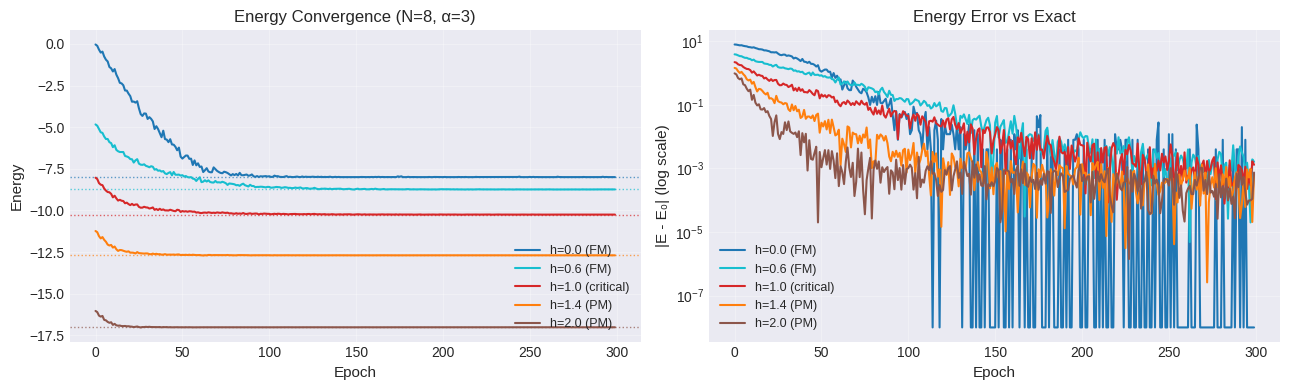


Final ΔE summary:
  h=0.0:  ΔE = +0.00000
  h=0.6:  ΔE = +0.00163
  h=1.0:  ΔE = +0.00131
  h=1.4:  ΔE = -0.00065
  h=2.0:  ΔE = +0.00074


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw energy
ax = axes[0]
for h in h_values:
    energies = results[h]["energies"]
    ax.plot(energies, color=h_colors[h], linewidth=1.5, label=h_labels[h])
    ax.axhline(
        exact_energies[h], color=h_colors[h], linewidth=1, linestyle=":", alpha=0.7
    )
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Energy", fontsize=11)
ax.set_title(f"Energy Convergence (N={N}, α={alpha})", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

# Right: energy error  |E_VMC - E0|  on log scale
ax = axes[1]
for h in h_values:
    energies = results[h]["energies"]
    E0 = exact_energies[h]
    errors = np.abs(np.array(energies) - E0)
    errors = np.maximum(errors, 1e-8)  # floor for log scale
    ax.semilogy(errors, color=h_colors[h], linewidth=1.5, label=h_labels[h])
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("|E - E₀| (log scale)", fontsize=11)
ax.set_title("Energy Error vs Exact", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/paper_energy_convergence.png", dpi=fig_dpi)
plt.show()

print("\nFinal ΔE summary:")
for h in h_values:
    dE = results[h]["energies"][-1] - exact_energies[h]
    print(f"  h={h:.1f}:  ΔE = {dE:+.5f}")

## Plot 2 — QFM Spectrum Evolution During Training

Reproduces Figure 2(b): eigenvalue spectrum at selected epochs.

**Key observation:** At epoch 0 all h values produce the same spectrum
(universal initial dynamics). As training progresses the spectra diverge
and encode the physical phase.


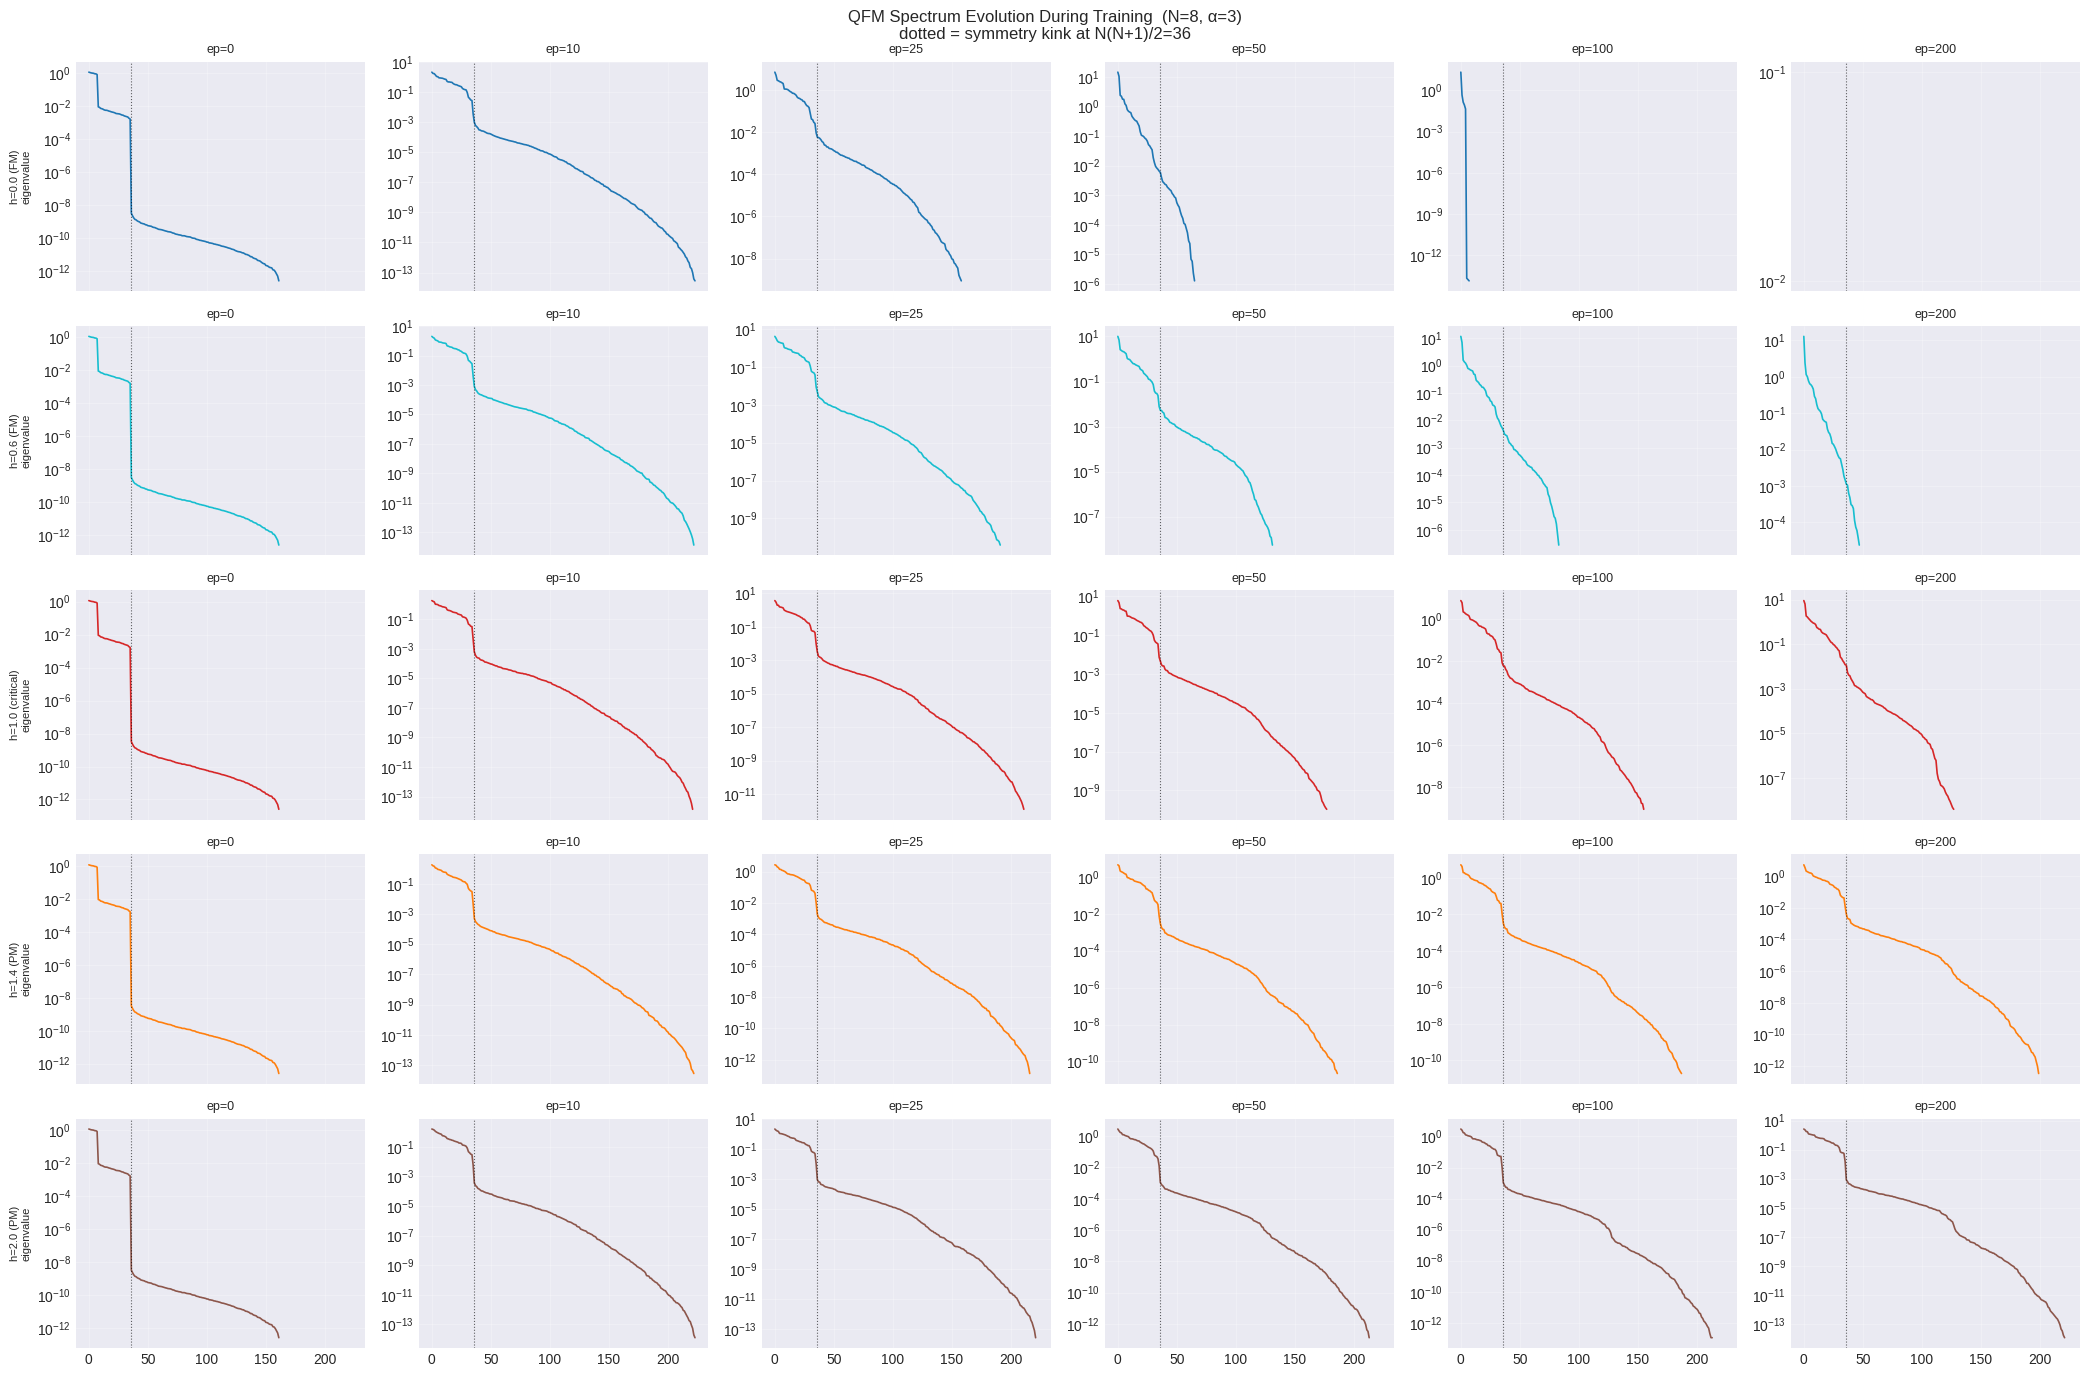

In [8]:
# Show epoch snapshots for each h value
sorted_epochs = sorted(qfm_snapshot_epochs)
n_snap = len(sorted_epochs)

fig, axes = plt.subplots(
    len(h_values), n_snap, figsize=(3.5 * n_snap, 2.8 * len(h_values)), sharex=True
)

for row, h in enumerate(h_values):
    snapshots = results[h]["qfm_snapshots"]
    for col, ep in enumerate(sorted_epochs):
        ax = axes[row, col]
        if ep not in snapshots:
            ax.axis("off")
            continue
        eigs = snapshots[ep]
        eigs_pos = eigs[eigs > 1e-14]
        ax.semilogy(
            np.arange(len(eigs_pos)), eigs_pos, color=h_colors[h], linewidth=1.2
        )
        ax.axvline(x=kink_idx, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
        ax.set_title(f"ep={ep}", fontsize=9)
        ax.grid(True, alpha=0.25)
        if col == 0:
            ax.set_ylabel(f"{h_labels[h]}\neigenvalue", fontsize=8)

fig.suptitle(
    f"QFM Spectrum Evolution During Training  (N={N}, α={alpha})\n"
    f"dotted = symmetry kink at N(N+1)/2={kink_idx}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("../results/paper_qfm_evolution.png", dpi=fig_dpi)
plt.show()

## Plot 3 — Converged QFM Spectra by Phase

Reproduces Figure 2(c): fully converged QFM eigenspectra on log-log scale.

**What to look for:**

- **h=0.0** (FM ground state = product state): nearly rank-1, spectrum collapses immediately
- **h=0.6** (ordered FM): rank-deficient, spectrum falls off before index N(N+1)/2
- **h=1.0** (critical): dense, smoothly exponential, all eigenvalues populated
- **h=1.4, 2.0** (PM): visible kink at N(N+1)/2, distinguishing Z₂ symmetric/antisymmetric subspaces


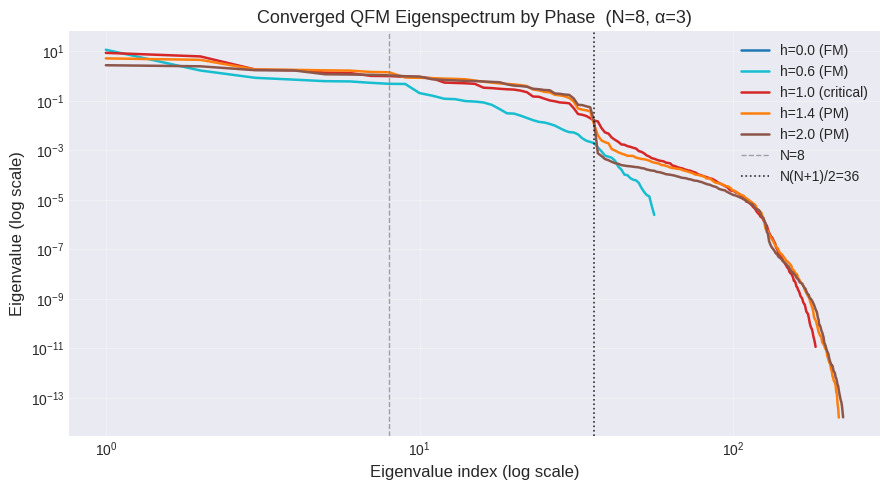


Non-zero eigenvalue counts (threshold 1e-14):
  h=0.0: 0/224 non-zero,  cond = 1.14e-05
  h=0.6: 56/224 non-zero,  cond = 1.18e+21
  h=1.0: 183/224 non-zero,  cond = 8.79e+20
  h=1.4: 217/224 non-zero,  cond = 5.25e+20
  h=2.0: 224/224 non-zero,  cond = 1.71e+14


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for h in h_values:
    eigs = results[h]["final_eigs"]
    eigs_pos = eigs[eigs > 1e-14]
    idx = np.arange(len(eigs_pos))
    ax.semilogy(idx + 1, eigs_pos, color=h_colors[h], linewidth=1.8, label=h_labels[h])

ax.axvline(x=N, color="gray", linewidth=1, linestyle="--", alpha=0.7, label=f"N={N}")
ax.axvline(
    x=kink_idx,
    color="black",
    linewidth=1.2,
    linestyle=":",
    alpha=0.8,
    label=f"N(N+1)/2={kink_idx}",
)

ax.set_xlabel("Eigenvalue index (log scale)", fontsize=12)
ax.set_ylabel("Eigenvalue (log scale)", fontsize=12)
ax.set_title(
    f"Converged QFM Eigenspectrum by Phase  (N={N}, α={alpha})",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/paper_qfm_converged.png", dpi=fig_dpi)
plt.show()

print("\nNon-zero eigenvalue counts (threshold 1e-14):")
for h in h_values:
    n_nonzero = np.sum(results[h]["final_eigs"] > 1e-14)
    ratio = results[h]["final_eigs"][0] / max(results[h]["final_eigs"][-1], 1e-20)
    print(f"  h={h:.1f}: {n_nonzero}/{n_params} non-zero,  cond = {ratio:.2e}")

## Plot 4 — Eigenvector Entanglement Entropy

Reproduces Figure 2(d): for each QFM eigenvector, the von Neumann entanglement
entropy of its W-block (visible ↔ hidden bipartition).

**Key finding:** The **largest eigenvalues** correspond to eigenvectors with
**near-zero entanglement** — they simply adjust the mean magnetization (first
moments) of the visible and hidden spins. Physical correlations are encoded
in the bulk of the spectrum — the many small eigenvalues that form the flat,
stable valleys of the parameter landscape.


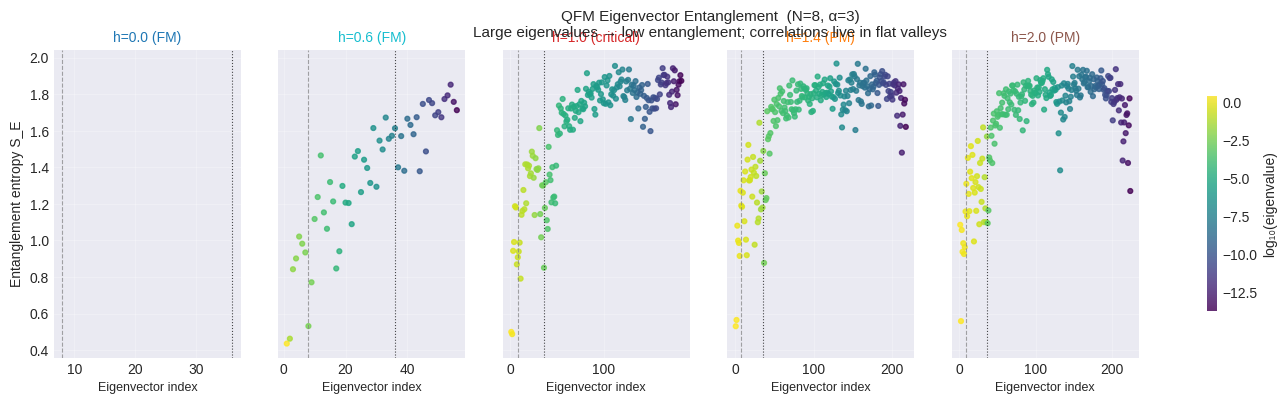

In [10]:
fig, axes = plt.subplots(
    1, len(h_values), figsize=(3.5 * len(h_values), 4), sharey=True
)

for ax, h in zip(axes, h_values):
    eigs = results[h]["final_eigs"]
    evecs = results[h]["final_evecs"]

    n_valid = np.sum(eigs > 1e-14)
    ent_vals = np.array(
        [
            eigenvector_entanglement(evecs[:, k], N, M)
            for k in range(min(n_valid, n_params))
        ]
    )

    eigs_valid = eigs[: len(ent_vals)]
    eigs_valid = np.maximum(eigs_valid, 1e-18)

    sc = ax.scatter(
        np.arange(len(ent_vals)) + 1,
        ent_vals,
        c=np.log10(eigs_valid),
        cmap="viridis",
        s=12,
        alpha=0.8,
    )
    ax.axvline(x=N, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axvline(x=kink_idx, color="black", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.set_title(h_labels[h], fontsize=10, color=h_colors[h])
    ax.set_xlabel("Eigenvector index", fontsize=9)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Entanglement entropy S_E", fontsize=10)

# Shared colourbar
cbar = fig.colorbar(sc, ax=axes, shrink=0.7, label="log₁₀(eigenvalue)")

fig.suptitle(
    f"QFM Eigenvector Entanglement  (N={N}, α={alpha})\n"
    "Large eigenvalues → low entanglement; correlations live in flat valleys",
    fontsize=11,
)
plt.savefig("../results/paper_entanglement.png", dpi=fig_dpi, bbox_inches="tight")
plt.show()

## Summary: Comparison with Exact Diagonalization


In [11]:
print(f"\nFinal energy comparison  (N={N}, α={alpha}, η={eta}, ε={epsilon})")
print(
    f"{'h':>5}  {'E_exact':>10}  {'E_VMC':>10}  {'ΔE':>10}  {'ΔE/N':>10}  QFM non-zero"
)
print("-" * 65)

for h in h_values:
    E0 = exact_energies[h]
    Ev = results[h]["energies"][-1]
    dE = Ev - E0
    nz = np.sum(results[h]["final_eigs"] > 1e-14)
    print(
        f"  {h:.1f}   {E0:10.5f}   {Ev:10.5f}   {dE:10.6f}   {dE/N:10.6f}   {nz}/{n_params}"
    )

print(f"\nSymmetry kink N(N+1)/2 = {kink_idx}  (visible in PM and critical spectra)")
print(f"\nTo scale to the paper's N=28: change N=8 → N=28 in the hyperparameters cell.")


Final energy comparison  (N=8, α=3, η=0.01, ε=0.001)
    h     E_exact       E_VMC          ΔE        ΔE/N  QFM non-zero
-----------------------------------------------------------------
  0.0     -8.00000     -8.00000     0.000000     0.000000   0/224
  0.6     -8.74083     -8.73920     0.001630     0.000204   56/224
  1.0    -10.25166    -10.25035     0.001310     0.000164   183/224
  1.4    -12.69623    -12.69688    -0.000654    -0.000082   217/224
  2.0    -17.01816    -17.01742     0.000744     0.000093   224/224

Symmetry kink N(N+1)/2 = 36  (visible in PM and critical spectra)

To scale to the paper's N=28: change N=8 → N=28 in the hyperparameters cell.


## Fix: Parallel Tempering for the Frozen h=0 Chain

### Why the simple Metropolis sampler fails at h=0

At h=0, the TFIM Hamiltonian $H = -\sum_i \sigma_i^z \sigma_{i+1}^z$ is purely diagonal.  
Its ground state is the ferromagnet $|\uparrow\uparrow\cdots\uparrow\rangle$ (or $|\downarrow\downarrow\cdots\downarrow\rangle$).  
The RBM correctly learns this state (ΔE = 0), but places almost all probability on one spin configuration.  
Every local spin-flip then proposes a configuration with **exponentially smaller amplitude**, so the Metropolis acceptance rate collapses to **0.000** after ~150 epochs.

With all 2000 final samples being identical configurations, the log-derivative matrix has zero variance → **S ≈ 0 → 0 non-zero eigenvalues**. The QFM cannot be computed.

### Parallel Tempering (paper recipe)

The paper uses **16 parallel chains** with inverse temperatures $\beta_k$ linearly spaced from $1/16$ (hot) to $1$ (physical/cold):

$$\beta_k = k/16, \quad k = 1, \ldots, 16$$

Chain $k$ samples from $|\Psi(\sigma)|^{2\beta_k}$:

- **Hot chain** ($\beta = 1/16$): distribution ≈ uniform → always moves freely
- **Cold chain** ($\beta = 1$): samples the physical $|\Psi|^2$

**Swap acceptance** between adjacent chains $c$ (hotter) and $c{+}1$ (colder):
$$A_\text{swap} = \min\!\left(1,\; \exp\!\left[2(\beta_c - \beta_{c+1})\bigl(\log|\Psi(\sigma_{c+1})| - \log|\Psi(\sigma_c)|\bigr)\right]\right)$$

Hot chains tunnel freely between ferromagnetic domains and pass diverse configurations to the cold chain via swaps — breaking the frozen-chain pathology.


Re-training h=0.0 with Parallel Tempering (16 chains)...
  epoch    1: E = -0.03600 ± 0.08699,  acc = 0.985
  epoch   50: E = -6.35600 ± 0.06859,  acc = 0.197
  epoch  100: E = -7.96800 ± 0.01127,  acc = 0.006
  epoch  150: E = -7.99600 ± 0.00400,  acc = 0.001
  epoch  200: E = -7.99600 ± 0.00400,  acc = 0.001
  epoch  250: E = -8.00000 ± 0.00000,  acc = 0.000
  epoch  300: E = -7.99600 ± 0.00400,  acc = 0.000

Final E (PT)  = -7.99600  (exact = -8.00000)
ΔE = +0.00400

Computing QFM from PT samples...
  Cold-chain acceptance: 0.000
  Non-zero eigenvalues: 6/224


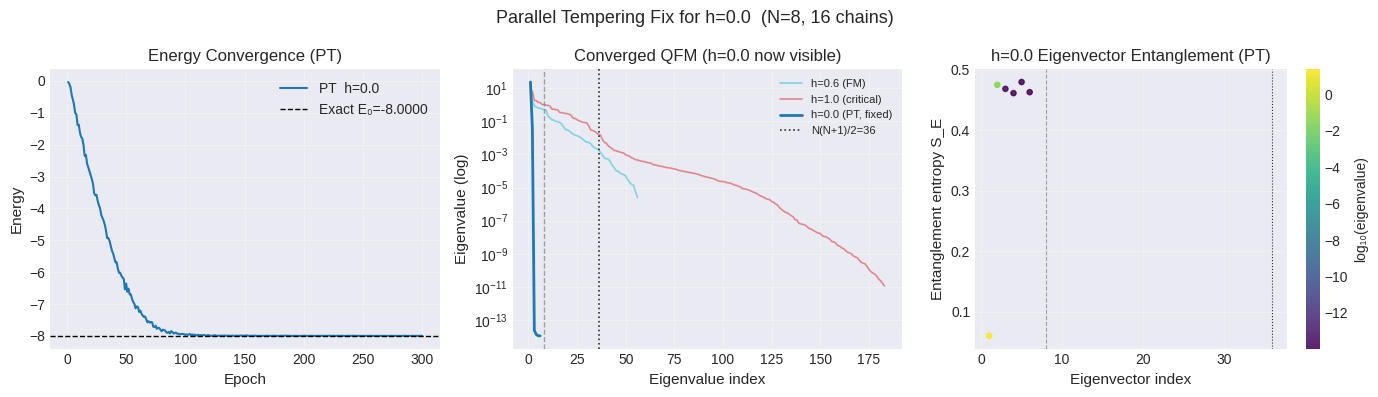


With PT: h=0.0 QFM has 6/224 non-zero eigenvalues
(previously 0/224 with frozen Metropolis chain)


In [12]:
# Reload the module to pick up the new parallel_tempering_sampler function
import importlib, complex_rbm as _crb

importlib.reload(_crb)
from complex_rbm import parallel_tempering_sampler

# ── Re-train h=0.0 with Parallel Tempering ─────────────────────────────────
print("Re-training h=0.0 with Parallel Tempering (16 chains)...")
theta_pt = init_rbm(N, M, scale=0.01, complex_params=False, seed=GLOBAL_SEED)
rng_pt = np.random.RandomState(GLOBAL_SEED)

energies_pt = []
for epoch in range(n_epochs):
    # Use PT for all sampling during training
    configs_pt, acc_pt = parallel_tempering_sampler(
        n_samples,
        N,
        theta_pt,
        N,
        n_chains=16,
        rng=rng_pt,
        n_burnin=50,
    )
    E_locs_pt = np.array(
        [local_energy_tfim(sigma, theta_pt, N, J=1.0, h=0.0) for sigma in configs_pt]
    )
    E_mean_pt = float(np.real(np.mean(E_locs_pt)))
    energies_pt.append(E_mean_pt)

    delta_pt = sr_update(configs_pt, np.real(E_locs_pt), theta_pt, sr_reg=epsilon)
    for k in theta_pt:
        theta_pt[k] -= eta * np.real(delta_pt[k])

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(
            f"  epoch {epoch+1:4d}: E = {E_mean_pt:8.5f} ± "
            f"{np.sqrt(np.var(E_locs_pt)/n_samples):.5f},  acc = {acc_pt:.3f}"
        )

print(f"\nFinal E (PT)  = {energies_pt[-1]:.5f}  (exact = {exact_energies[0.0]:.5f})")
print(f"ΔE = {energies_pt[-1] - exact_energies[0.0]:+.5f}")

# ── QFM with PT samples ─────────────────────────────────────────────────────
print("\nComputing QFM from PT samples...")
qfm_configs_pt, acc_final = parallel_tempering_sampler(
    2000,
    N,
    theta_pt,
    N,
    n_chains=16,
    rng=np.random.RandomState(9999),
    n_burnin=500,
)
print(f"  Cold-chain acceptance: {acc_final:.3f}")
S_pt, _ = build_qfm(qfm_configs_pt, theta_pt)
eigs_pt, evecs_pt = qfm_spectrum(S_pt)
n_nz_pt = np.sum(eigs_pt > 1e-14)
print(f"  Non-zero eigenvalues: {n_nz_pt}/{n_params}")

# ── Compare spectra: plain Metropolis (h=0, broken) vs PT (fixed) ───────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(
    np.arange(1, n_epochs + 1),
    energies_pt,
    color="#1f77b4",
    linewidth=1.5,
    label="PT  h=0.0",
)
ax.axhline(
    exact_energies[0.0],
    color="black",
    linewidth=1,
    linestyle="--",
    label=f"Exact E₀={exact_energies[0.0]:.4f}",
)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Energy", fontsize=11)
ax.set_title("Energy Convergence (PT)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for h_ref in [0.6, 1.0]:
    eigs_ref = results[h_ref]["final_eigs"]
    ax.semilogy(
        np.arange(1, np.sum(eigs_ref > 1e-14) + 1),
        eigs_ref[eigs_ref > 1e-14],
        color=h_colors[h_ref],
        linewidth=1.2,
        alpha=0.5,
        label=h_labels[h_ref],
    )
eigs_pos = eigs_pt[eigs_pt > 1e-14]
ax.semilogy(
    np.arange(1, len(eigs_pos) + 1),
    eigs_pos,
    color="#1f77b4",
    linewidth=2.0,
    label="h=0.0 (PT, fixed)",
)
ax.axvline(x=N, color="gray", linewidth=1, linestyle="--", alpha=0.7)
ax.axvline(
    x=kink_idx,
    color="black",
    linewidth=1.2,
    linestyle=":",
    alpha=0.8,
    label=f"N(N+1)/2={kink_idx}",
)
ax.set_xlabel("Eigenvalue index", fontsize=11)
ax.set_ylabel("Eigenvalue (log)", fontsize=11)
ax.set_title("Converged QFM (h=0.0 now visible)", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
n_valid_pt = min(n_nz_pt, n_params)
ent_pt = np.array(
    [eigenvector_entanglement(evecs_pt[:, k], N, M) for k in range(n_valid_pt)]
)
eigs_plot = np.maximum(eigs_pt[:n_valid_pt], 1e-18)
sc = ax.scatter(
    np.arange(n_valid_pt) + 1,
    ent_pt,
    c=np.log10(eigs_plot),
    cmap="viridis",
    s=14,
    alpha=0.85,
)
ax.axvline(x=N, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
ax.axvline(x=kink_idx, color="black", linewidth=0.8, linestyle=":", alpha=0.8)
ax.set_xlabel("Eigenvector index", fontsize=11)
ax.set_ylabel("Entanglement entropy S_E", fontsize=11)
ax.set_title("h=0.0 Eigenvector Entanglement (PT)", fontsize=12)
plt.colorbar(sc, ax=ax, label="log₁₀(eigenvalue)")
ax.grid(True, alpha=0.25)

plt.suptitle(f"Parallel Tempering Fix for h=0.0  (N={N}, {16} chains)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/paper_pt_fix_h0.png", dpi=fig_dpi)
plt.show()

print(f"\nWith PT: h=0.0 QFM has {n_nz_pt}/{n_params} non-zero eigenvalues")
print("(previously 0/224 with frozen Metropolis chain)")